In [7]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

sns.set_theme(style="whitegrid", palette="deep")

DATA_PATH = Path("../data/dataset_delivery_time_clean.csv")
df = pd.read_csv(DATA_PATH)

print(f"Dimensions : {df.shape[0]:,} lignes x {df.shape[1]} colonnes")
display(df.head())
display(df.dtypes.rename("dtype").to_frame())
print(f"Valeurs manquantes : {df.isna().sum().sum()}")

Dimensions : 41,934 lignes x 7 colonnes


,Time_Order_picked,Weatherconditions,Road_traffic_density,Type_of_vehicle,Time_taken(min),Distance_km,Order_hour
0,11:45:00,Sunny,High,motorcycle,24,3.025149,11
1,19:50:00,Stormy,Jam,scooter,33,20.183530,19
2,08:45:00,Sandstorms,Low,motorcycle,26,1.552758,8
3,18:10:00,Sunny,Medium,motorcycle,21,7.790401,18
4,13:45:00,Cloudy,High,scooter,30,6.210138,13


,dtype
Time_Order_picked,str
Weatherconditions,str
Road_traffic_density,str
Type_of_vehicle,str
Time_taken(min),int64
Distance_km,float64
Order_hour,int64


Valeurs manquantes : 0


# Analyse exploratoire du temps de livraison

Objectif : comprendre les facteurs associés à `Time_taken(min)` et préparer des variables utiles pour la modélisation. Les résultats sont calculés sur `dataset_delivery_time_clean.csv`.

Statistiques descriptives des variables numériques


,count,mean,median,std,min,max
Time_taken(min),41934.0,26.31,26.00,9.38,10.00,54.00
Distance_km,41934.0,9.72,9.19,5.60,1.47,20.97
Order_hour,41934.0,17.15,19.00,5.32,0.00,23.00


Fréquences des variables catégorielles

Weatherconditions


,count,percentage
Weatherconditions,,
Fog,7578,18.07
Stormy,6970,16.62
Cloudy,6929,16.52
Sandstorms,6902,16.46
Windy,6830,16.29
Sunny,6725,16.04



Road_traffic_density


,count,percentage
Road_traffic_density,,
Low,14747,35.17
Jam,13036,31.09
Medium,10083,24.04
High,4068,9.70



Type_of_vehicle


,count,percentage
Type_of_vehicle,,
motorcycle,24382,58.14
scooter,14024,33.44
electric_scooter,3468,8.27
bicycle,60,0.14


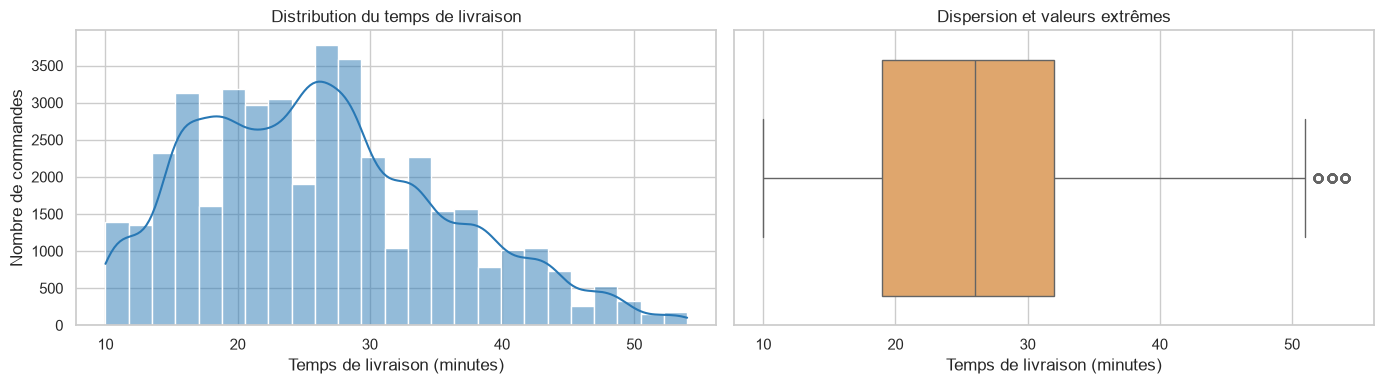

In [8]:
target = "Time_taken(min)"
num_cols = ["Time_taken(min)", "Distance_km", "Order_hour"]
cat_cols = ["Weatherconditions", "Road_traffic_density", "Type_of_vehicle"]

print("Statistiques descriptives des variables numériques")
stats = df[num_cols].describe().T[["count", "mean", "50%", "std", "min", "max"]]
stats = stats.rename(columns={"50%": "median"}).round(2)
display(stats)

print("Fréquences des variables catégorielles")
for column in cat_cols:
    frequencies = (
        df[column]
        .value_counts(dropna=False)
        .rename("count")
        .to_frame()
        .assign(percentage=lambda table: (100 * table["count"] / len(df)).round(2))
    )
    print(f"\n{column}")
    display(frequencies)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
sns.histplot(data=df, x=target, bins=25, kde=True, ax=axes[0], color="#2878b5")
axes[0].set_title("Distribution du temps de livraison")
axes[0].set_xlabel("Temps de livraison (minutes)")
axes[0].set_ylabel("Nombre de commandes")
sns.boxplot(data=df, x=target, ax=axes[1], color="#f2a65a")
axes[1].set_title("Dispersion et valeurs extrêmes")
axes[1].set_xlabel("Temps de livraison (minutes)")
plt.tight_layout()
plt.show()

Relations entre la cible et les variables numériques


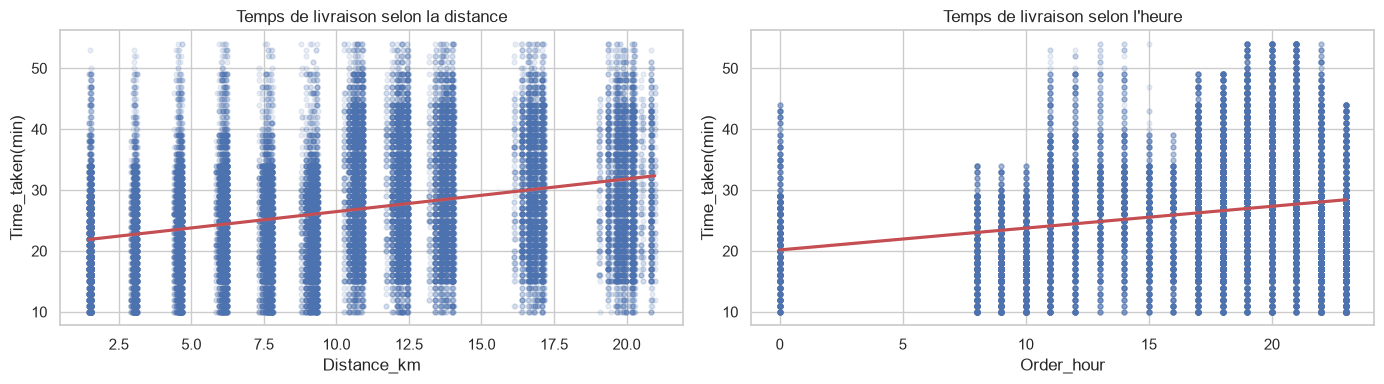


Weatherconditions : temps de livraison par modalité


,mean,median,std,count
Weatherconditions,,,,
Cloudy,28.92,29.0,10.02,6929
Fog,28.78,28.0,10.10,7578
Windy,26.13,26.0,8.62,6830
Stormy,25.90,26.0,8.49,6970
Sandstorms,25.88,26.0,8.64,6902
Sunny,21.90,20.0,8.36,6725



Road_traffic_density : temps de livraison par modalité


,mean,median,std,count
Road_traffic_density,,,,
Jam,31.18,31.0,9.94,13036
High,27.23,27.0,8.42,4068
Medium,26.73,27.0,8.53,10083
Low,21.47,21.0,7.00,14747



Type_of_vehicle : temps de livraison par modalité


,mean,median,std,count
Type_of_vehicle,,,,
motorcycle,27.61,26.0,9.64,24382
bicycle,26.42,26.5,8.96,60
scooter,24.51,24.0,8.71,14024
electric_scooter,24.46,24.0,8.64,3468


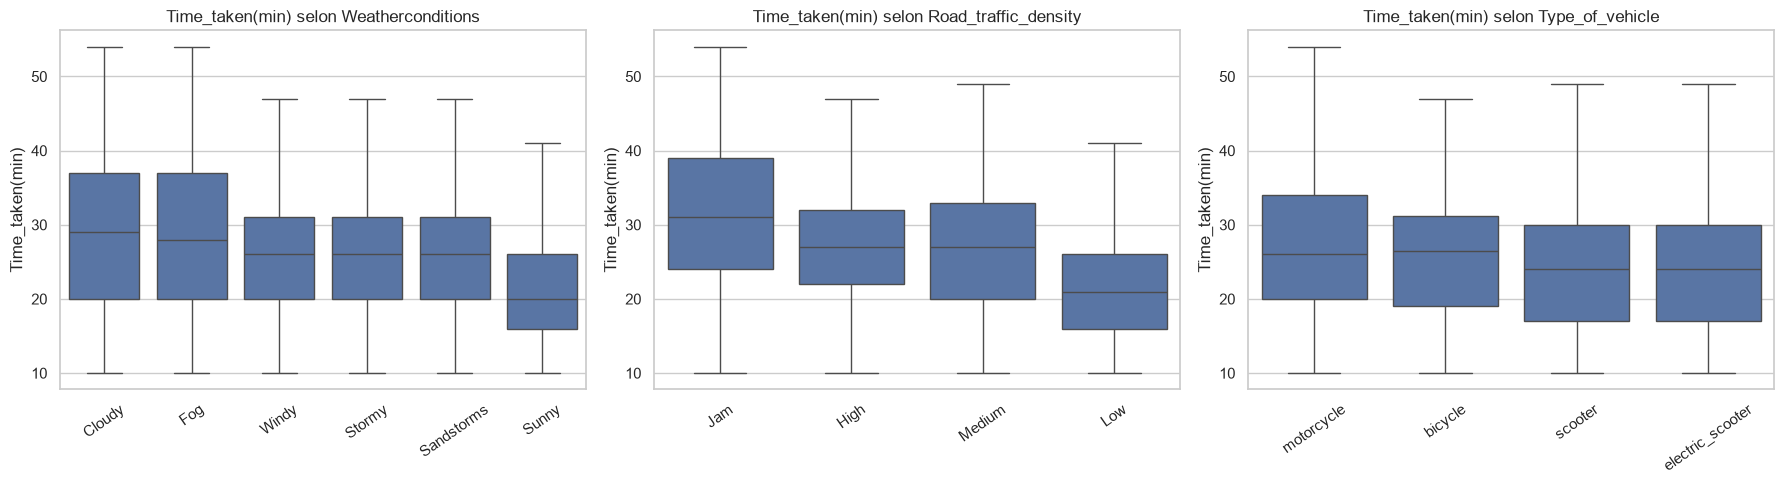

La variable Time_Order_picked est représentée par Order_hour, qui permet une analyse numérique et évite de traiter l'heure comme une chaîne de caractères.


In [9]:
print("Relations entre la cible et les variables numériques")
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
sns.regplot(data=df, x="Distance_km", y=target, scatter_kws={"alpha": 0.12, "s": 12}, line_kws={"color": "#c44e52"}, ax=axes[0])
axes[0].set_title("Temps de livraison selon la distance")
sns.regplot(data=df, x="Order_hour", y=target, scatter_kws={"alpha": 0.12, "s": 12}, line_kws={"color": "#c44e52"}, ax=axes[1])
axes[1].set_title("Temps de livraison selon l'heure")
plt.tight_layout()
plt.show()

grouped_means = {}
for column in cat_cols:
    grouped_means[column] = df.groupby(column, observed=True)[target].agg(["mean", "median", "std", "count"]).sort_values("mean", ascending=False).round(2)
    print(f"\n{column} : temps de livraison par modalité")
    display(grouped_means[column])

fig, axes = plt.subplots(1, len(cat_cols), figsize=(18, 5))
for ax, column in zip(axes, cat_cols):
    order = df.groupby(column, observed=True)[target].mean().sort_values(ascending=False).index
    sns.boxplot(data=df, x=column, y=target, order=order, ax=ax, showfliers=False)
    ax.set_title(f"{target} selon {column}")
    ax.tick_params(axis="x", rotation=35)
    ax.set_xlabel("")
plt.tight_layout()
plt.show()

print("La variable Time_Order_picked est représentée par Order_hour, qui permet une analyse numérique et évite de traiter l'heure comme une chaîne de caractères.")

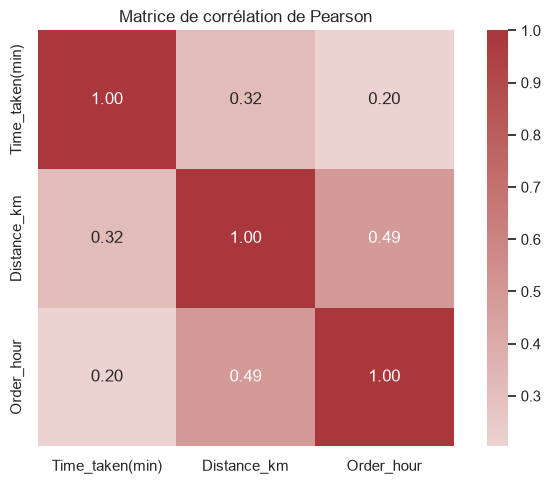

Forces d'association avec la cible


,abs_correlation
Distance_km,0.320450
Order_hour,0.203159


,eta_squared
Road_traffic_density,0.178906
Weatherconditions,0.061514
Type_of_vehicle,0.026626


Interprétation : la corrélation mesure une association linéaire pour les variables numériques. Eta² mesure la part de variance de la cible associée aux groupes d'une variable catégorielle; ce n'est pas une preuve de causalité.


In [10]:
corr = df[num_cols].corr(numeric_only=True)
plt.figure(figsize=(7, 5))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="vlag", center=0, square=True)
plt.title("Matrice de corrélation de Pearson")
plt.tight_layout()
plt.show()

def eta_squared(dataframe, category, response):
    overall_mean = dataframe[response].mean()
    between = dataframe.groupby(category, observed=True).apply(
        lambda group: len(group) * (group[response].mean() - overall_mean) ** 2,
        include_groups=False,
    ).sum()
    total = ((dataframe[response] - overall_mean) ** 2).sum()
    return between / total

numeric_strength = df[num_cols].corr(numeric_only=True)[target].drop(target).abs().sort_values(ascending=False)
category_strength = pd.Series({column: eta_squared(df, column, target) for column in cat_cols}).sort_values(ascending=False)

print("Forces d'association avec la cible")
display(numeric_strength.rename("abs_correlation").to_frame())
display(category_strength.rename("eta_squared").to_frame())
print(
    "Interprétation : la corrélation mesure une association linéaire pour les variables numériques. "
    "Eta² mesure la part de variance de la cible associée aux groupes d'une variable catégorielle; "
    "ce n'est pas une preuve de causalité."
)

In [14]:
df_features = df.copy()

traffic_mapping = {"Low": 0, "Medium": 1, "High": 2, "Jam": 3}
df_features["Traffic_score"] = df_features["Road_traffic_density"].map(traffic_mapping)
df_features["Is_peak_hour"] = df_features["Order_hour"].between(12, 14) | df_features["Order_hour"].between(18, 21)
df_features["Distance_x_traffic"] = df_features["Distance_km"] * df_features["Traffic_score"]
df_features["Hour_sin"] = __import__("numpy").sin(2 * __import__("numpy").pi * df_features["Order_hour"] / 24)
df_features["Hour_cos"] = __import__("numpy").cos(2 * __import__("numpy").pi * df_features["Order_hour"] / 24)
df_features["Time_of_day"] = pd.cut(
    df_features["Order_hour"],
    bins=[-1, 5, 11, 17, 23],
    labels=["Nuit", "Matin", "Apres-midi", "Soir"],
)

new_features = [
    "Traffic_score",
    "Is_peak_hour",
    "Distance_x_traffic",
    "Hour_sin",
    "Hour_cos",
    "Time_of_day",
]

print("Nouvelles variables créées")
display(df_features[new_features].head())
print("\nContrôle des nouvelles variables numériques")
display(df_features[[target] + [feature for feature in new_features if df_features[feature].dtype != "category"]].corr(numeric_only=True)[target].drop(target).sort_values(key=abs, ascending=False).rename("correlation").to_frame().round(3))
print(
    "\nCes features enrichissent le modèle sans utiliser la cible : Traffic_score et Is_peak_hour "
    "résument les régimes de circulation, Distance_x_traffic modélise leur interaction, "
    "et Hour_sin/Hour_cos représentent correctement le caractère cyclique de l'heure."
)

Nouvelles variables créées


,Traffic_score,Is_peak_hour,Distance_x_traffic,Hour_sin,Hour_cos,Time_of_day
0,2,False,6.050299,0.258819,-9.659258e-01,Matin
1,3,True,60.550589,-0.965926,2.588190e-01,Soir
2,0,False,0.000000,0.866025,-5.000000e-01,Matin
3,1,True,7.790401,-1.000000,-1.836970e-16,Soir
4,2,True,12.420276,-0.258819,-9.659258e-01,Apres-midi



Contrôle des nouvelles variables numériques


,correlation
Distance_x_traffic,0.437
Traffic_score,0.412
Is_peak_hour,0.339
Hour_sin,-0.327
Hour_cos,0.114



Ces features enrichissent le modèle sans utiliser la cible : Traffic_score et Is_peak_hour résument les régimes de circulation, Distance_x_traffic modélise leur interaction, et Hour_sin/Hour_cos représentent correctement le caractère cyclique de l'heure.


## Synthèse

- Le temps de livraison moyen est de **26,31 minutes**, avec une médiane de **26 minutes** et un écart-type de **9,38 minutes**.
- `Distance_km` est la variable numérique la plus fortement liée à la cible ($|r| = 0,320$), mais l'association reste modérée et ne décrit pas toute la relation.
- `Road_traffic_density` est la variable catégorielle la plus discriminante ($\eta^2 = 0,179$) : la moyenne est de **31,18 minutes** en situation `Jam` contre **21,47 minutes** en situation `Low`.
- `Weatherconditions` présente une association plus faible mais visible; `Cloudy` et `Fog` ont les temps moyens les plus élevés, tandis que `Sunny` est le plus faible.
- `Type_of_vehicle` a une association limitée et doit être interprétée avec prudence, car la modalité `bicycle` ne compte que 60 observations.
- Les nouvelles features recommandées sont `Traffic_score`, `Is_peak_hour`, `Distance_x_traffic`, `Hour_sin`, `Hour_cos` et `Time_of_day`. Elles capturent les effets non linéaires, cycliques et d'interaction que les variables brutes représentent imparfaitement.

Les associations observées sont descriptives et ne prouvent pas une causalité. La prochaine étape est de comparer ces variables dans une validation croisée du modèle de prédiction.